## Script for statistics of binary relevance and classifier chains


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import utils
import os
from sklearn.metrics import jaccard_score, roc_auc_score, f1_score

In [3]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/"

ini_results_filepath_ml = "../prediction_results/INI_results/"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



In [12]:
files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs = {}
jacc_macro = {}


for path in filepath_list:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = roc_auc_score(true_labels, pred_labels, average="macro", multi_class="ovr")

        #print(jaccard_score(true_labels, pred_labels, average="samples"))
        #print(jaccard_score(true_labels, pred_labels, average="macro"))
        acc_list.append(sub_acc)

    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})



print(sub_accs)



file = "_results/Binary_complete_labels_Multilabel_prediction.csv"


#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs_old = []

targets = ["PI", "NNRTI", "NRTI", "INI"]

for path, target in zip(filepath_list_ml, targets):

    df_old_ml_pred = pd.DataFrame()

    drugs = [file_name.strip("_results") for file_name in os.listdir(path) if "_results" in file_name]

    #acc_list = []


    for drug in drugs:
        results = pd.read_csv(path + drug + file)

        df_old_ml_pred["True_" + drug] = results["True"]

        #print(drug)

        df_old_ml_pred["Pred_" + drug] = [1.0 if proba >= 0.5 else 0.0 for proba in results["1"]]

    #print(df_old_ml_pred)

    true_labels = df_old_ml_pred.filter(regex="True_*")
    pred_labels = df_old_ml_pred.filter(regex="Pred_*")

    #print(true_labels)
    #print(pred_labels)

    sub_accs[target].append(jaccard_score(true_labels, pred_labels, average="macro"))

#print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)



{'PI': [0.9234432466175921, 0.9157771027909014, 0.9147526942128731], 'NNRTI': [0.8245225999311314, 0.8562964250401681, 0.8747017610160137], 'NRTI': [0.8824591422213953, 0.8893306776896573, 0.8901992034957554], 'INI': [0.867595618214059, 0.8220911949685534, 0.8893081761006288]}


Axes(0.125,0.53;0.352273x0.35)
0
Axes(0.547727,0.53;0.352273x0.35)
1
Axes(0.125,0.11;0.352273x0.35)
2
Axes(0.547727,0.11;0.352273x0.35)
3


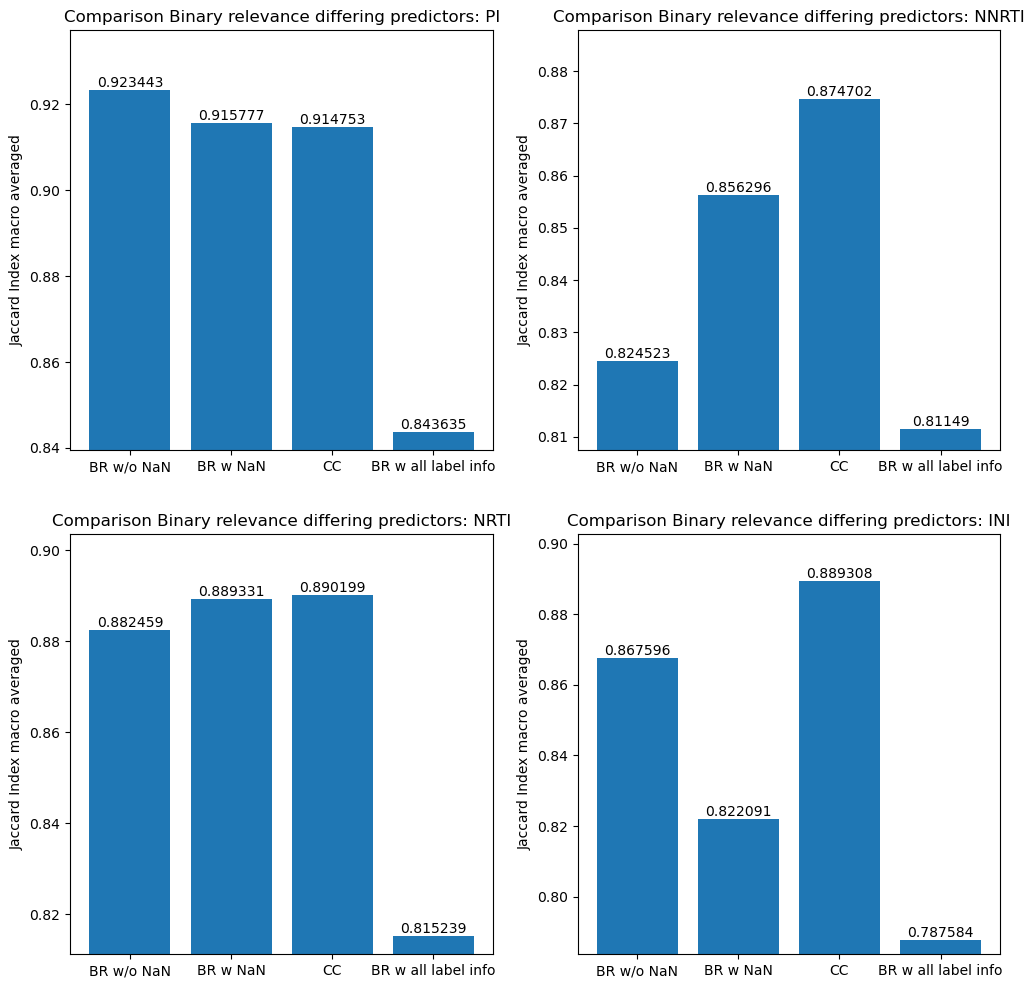

In [13]:
models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC", "BR w all label info"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    print(axs[i])
    print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs[drug])

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Jaccard Index macro averaged')
    axs[i].set_ylim(max(0, df_sub_accs[drug].min()* 0.995), min(1.0, df_sub_accs[drug].max()  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)




#plt.savefig("../figures/BR_CC_comparison.png")


{'PI': [0.6578171091445427, 0.7117572692793932, 0.706700379266751], 'NNRTI': [0.6896551724137931, 0.8253968253968254, 0.8333333333333334], 'NRTI': [0.5732368896925859, 0.6033519553072626, 0.6131284916201117], 'INI': [0.6274509803921569, 0.7944664031620553, 0.8102766798418972]}
Axes(0.125,0.53;0.352273x0.35)
0
Axes(0.547727,0.53;0.352273x0.35)
1
Axes(0.125,0.11;0.352273x0.35)
2
Axes(0.547727,0.11;0.352273x0.35)
3


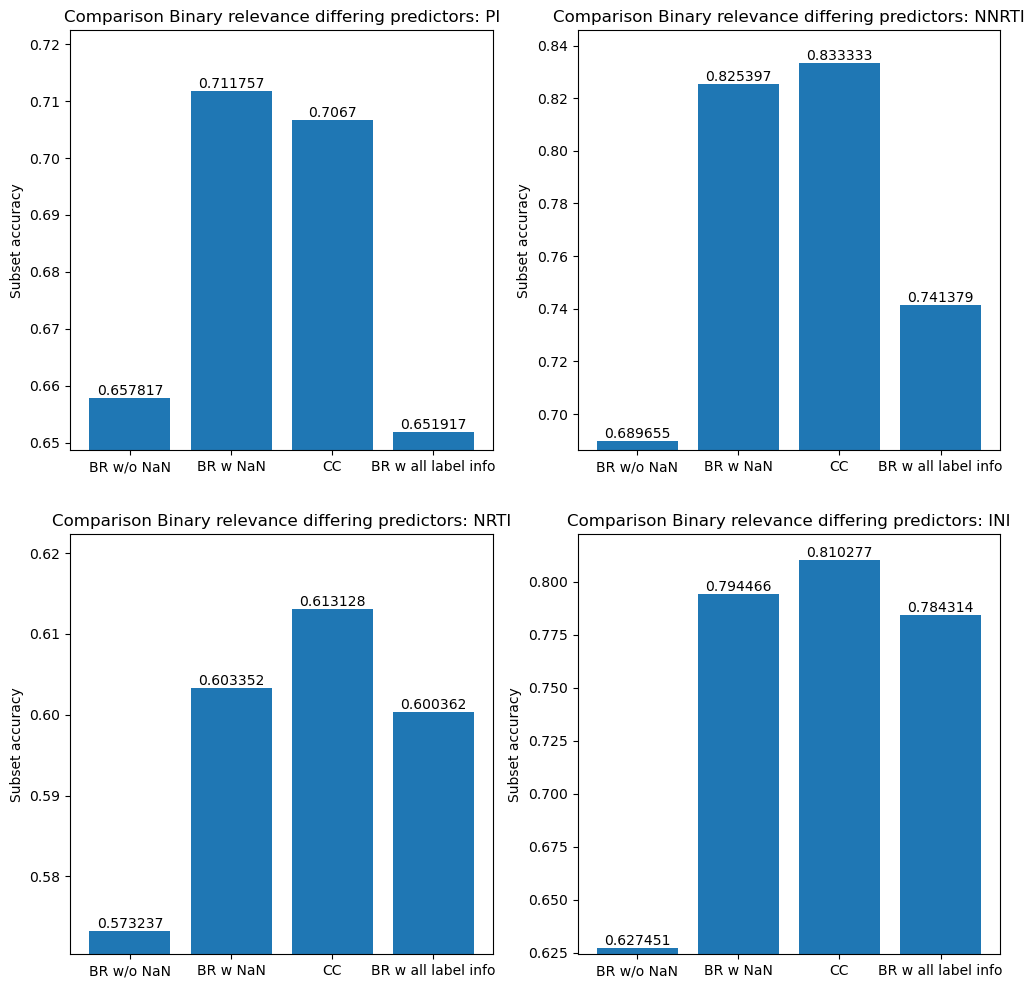

In [10]:
"""subset accuracy ignoring missing labels"""

files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs = {}



for path in filepath_list:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        acc_list.append(sub_acc)

    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})



print(sub_accs)



file = "_results/Binary_complete_labels_Multilabel_prediction.csv"


#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs_old = []

targets = ["PI", "NNRTI", "NRTI", "INI"]

for path, target in zip(filepath_list_ml, targets):

    df_old_ml_pred = pd.DataFrame()

    drugs = [file_name.strip("_results") for file_name in os.listdir(path) if "_results" in file_name]

    #acc_list = []


    for drug in drugs:
        results = pd.read_csv(path + drug + file)

        df_old_ml_pred["True_" + drug] = results["True"]

        #print(drug)

        df_old_ml_pred["Pred_" + drug] = [1.0 if proba >= 0.5 else 0.0 for proba in results["1"]]

    #print(df_old_ml_pred)

    true_labels = df_old_ml_pred.filter(regex="True_*")
    pred_labels = df_old_ml_pred.filter(regex="Pred_*")

    #print(true_labels)
    #print(pred_labels)

    sub_accs[target].append(utils.subset_acc(pred_labels, true_labels))

#print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC", "BR w all label info"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    print(axs[i])
    print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs[drug])

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, df_sub_accs[drug].min()* 0.995), min(1.0, df_sub_accs[drug].max()  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)




plt.savefig("../figures/BR_CC_comparison_woNaN.png")



In [11]:
files = ["Binary_Relevance_5_fold_MOC_prediction.csv", "Binary_Relevance_5_fold_homebrew_prediction.csv", "Classifier_Chain_5_fold_homebrew_prediction.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*")), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)


#plt.bar(df_sub_accs)

In [12]:
df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

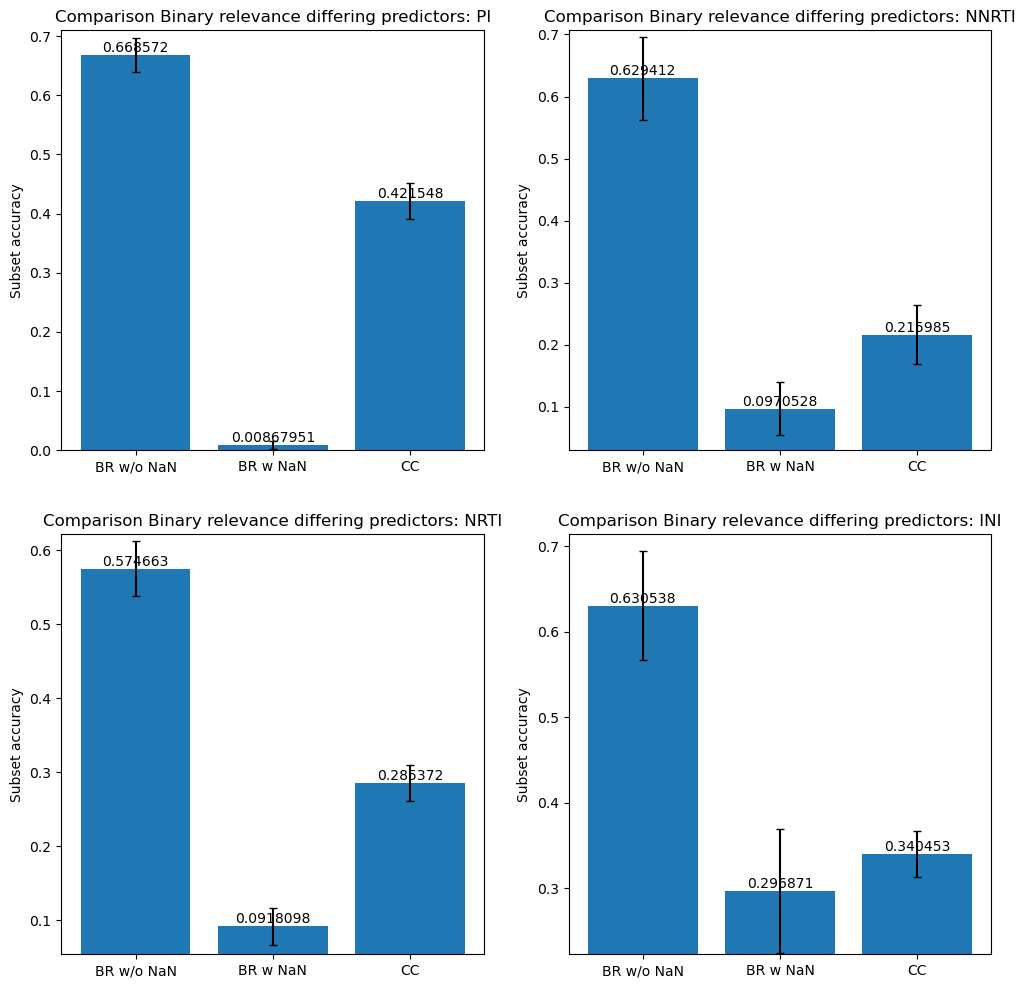

In [13]:
models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/BR_CC_kfold_model_comparison.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


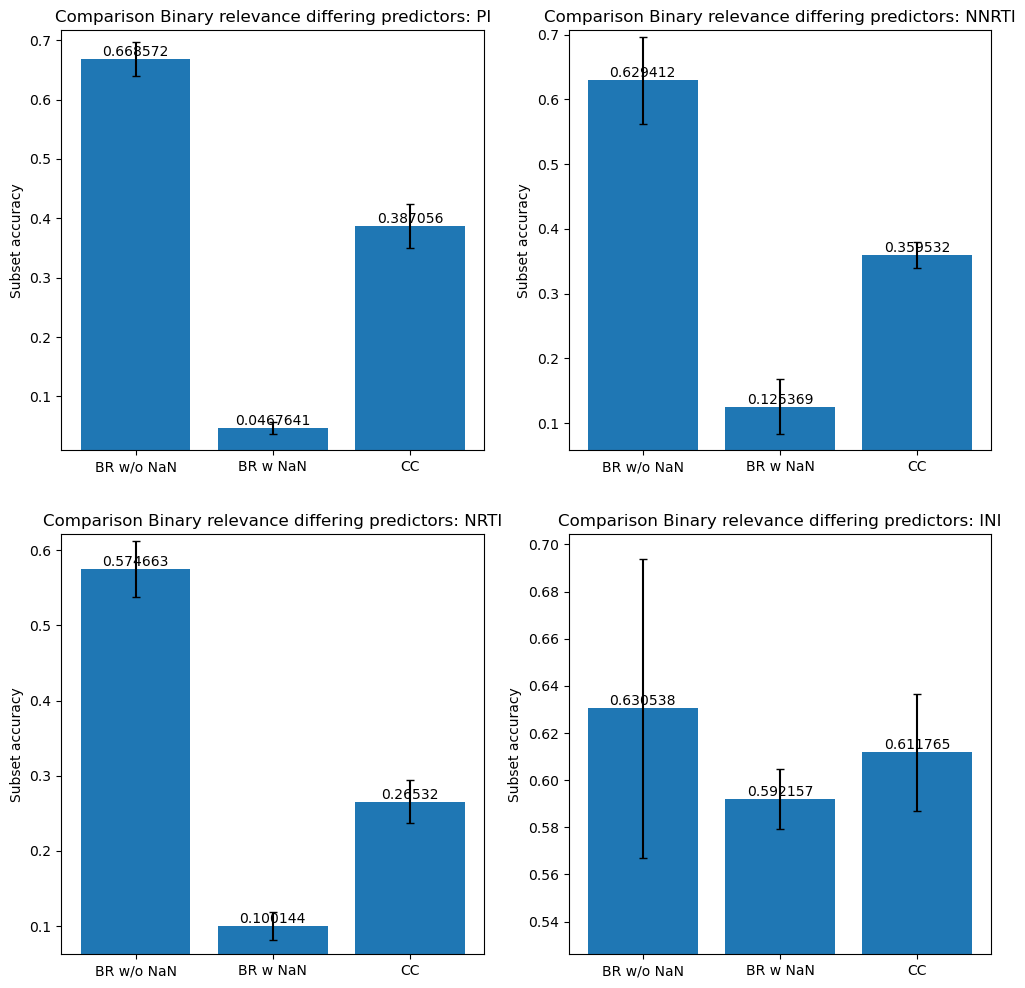

In [14]:
files = ["Binary_Relevance_5_fold_MOC_prediction.csv", "Binary_Relevance_5_fold_homebrew_prediction.csv", "Classifier_Chain_5_fold_homebrew_prediction.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/BR_CC_kfold_model_comparison_woNaN.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


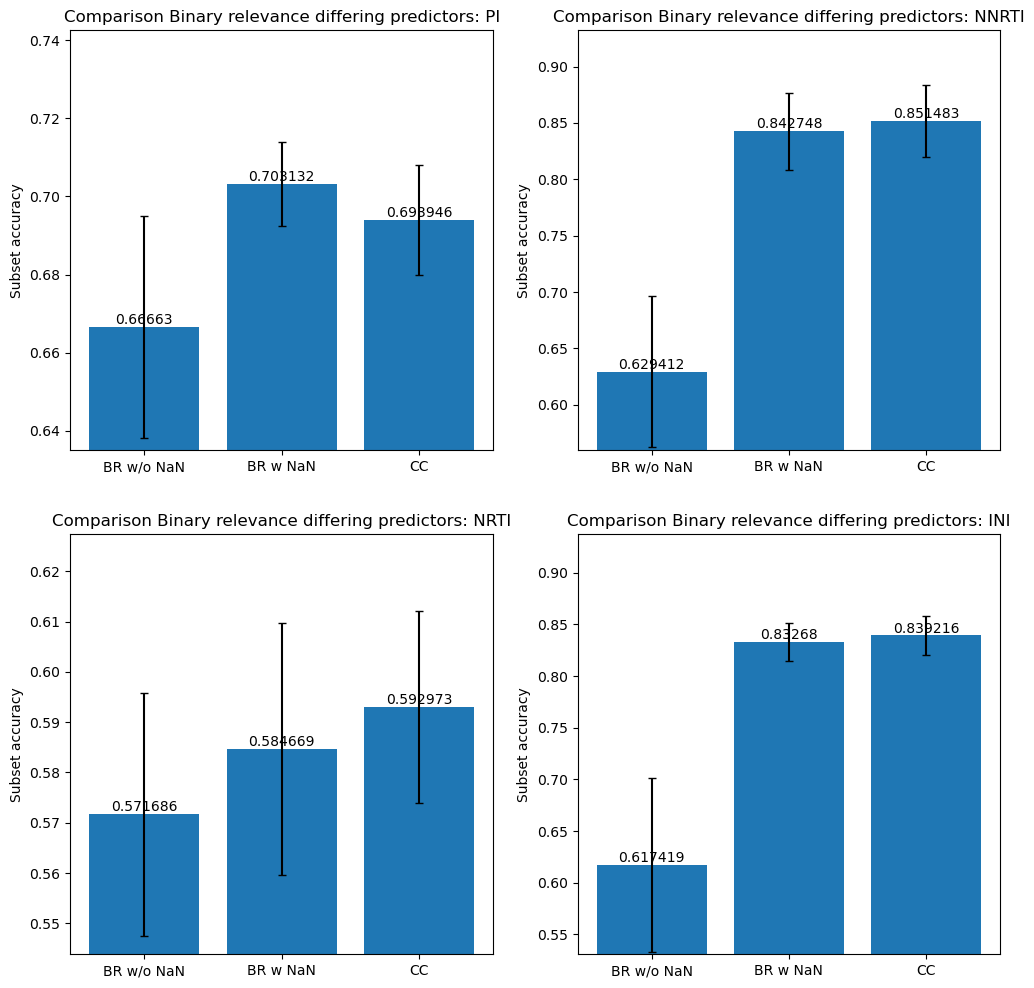

In [3]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv",  "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


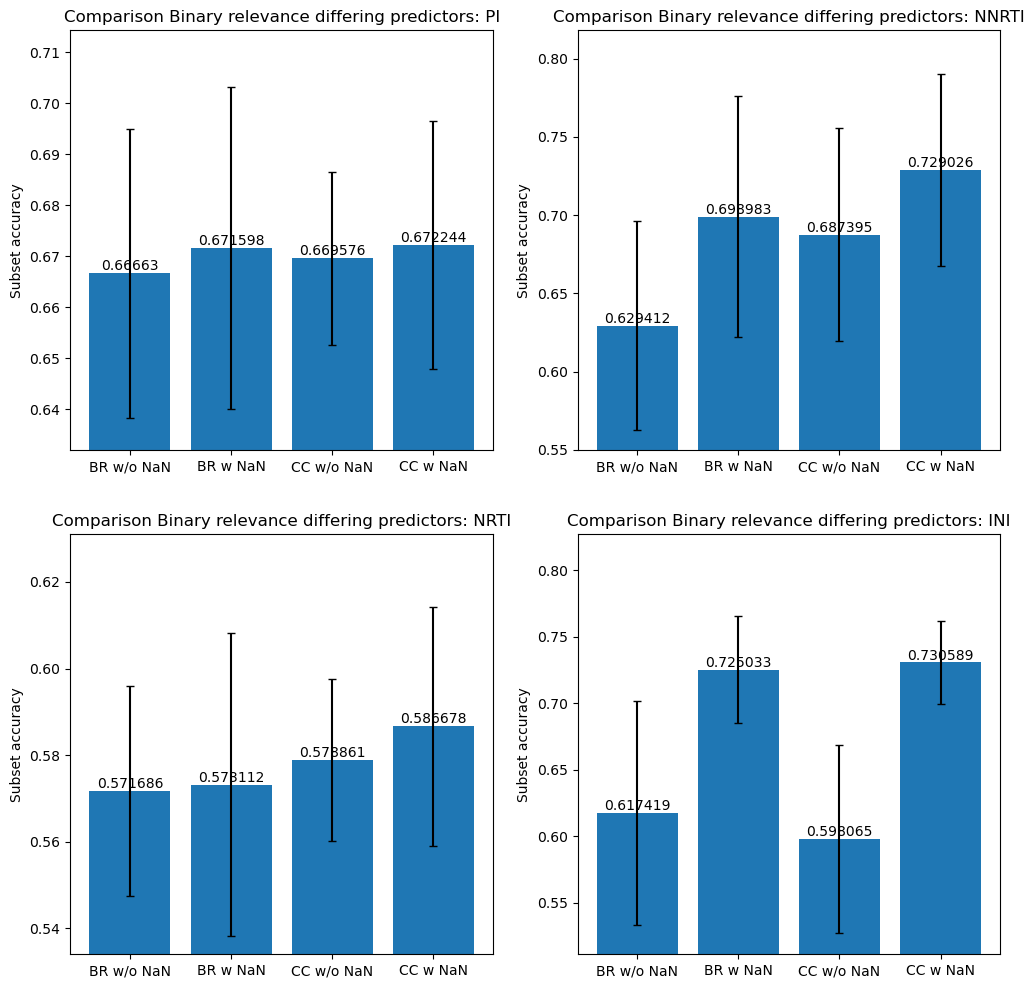

In [4]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


#plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new_wCCNaN.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


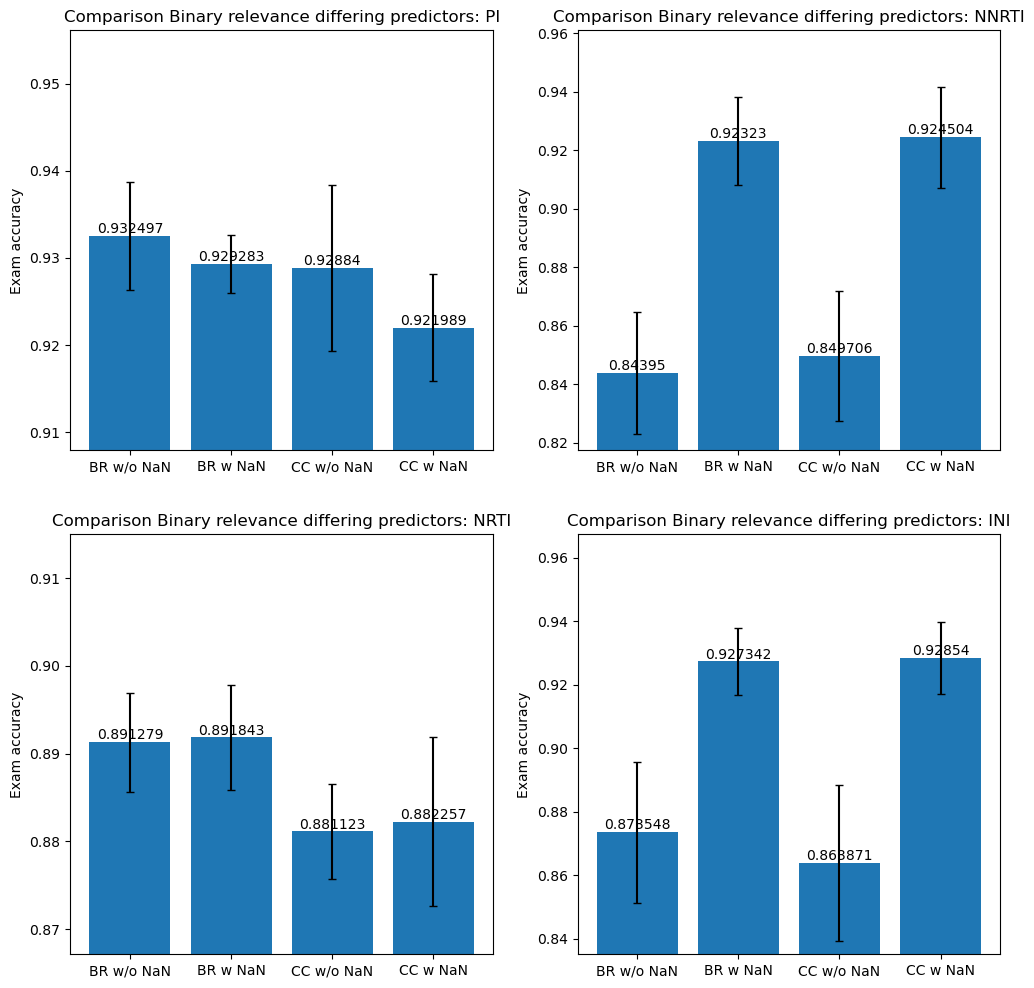

In [7]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new_wCCNaN_examAcc.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


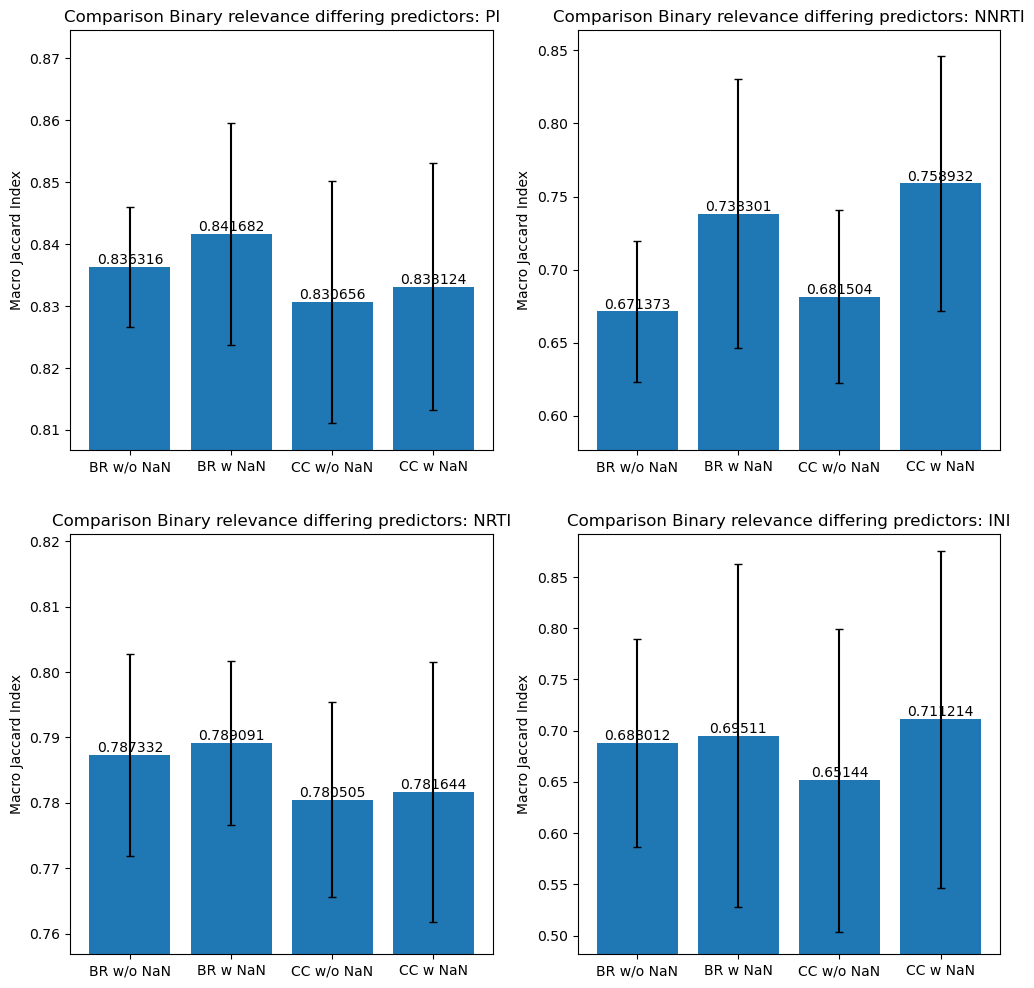

In [26]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: jaccard_score(x.filter(regex="True_*"),x.filter(regex="Pred_*"), average="macro", zero_division="warn"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Macro Jaccard Index')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new_wCCNaN_jaccMacro.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


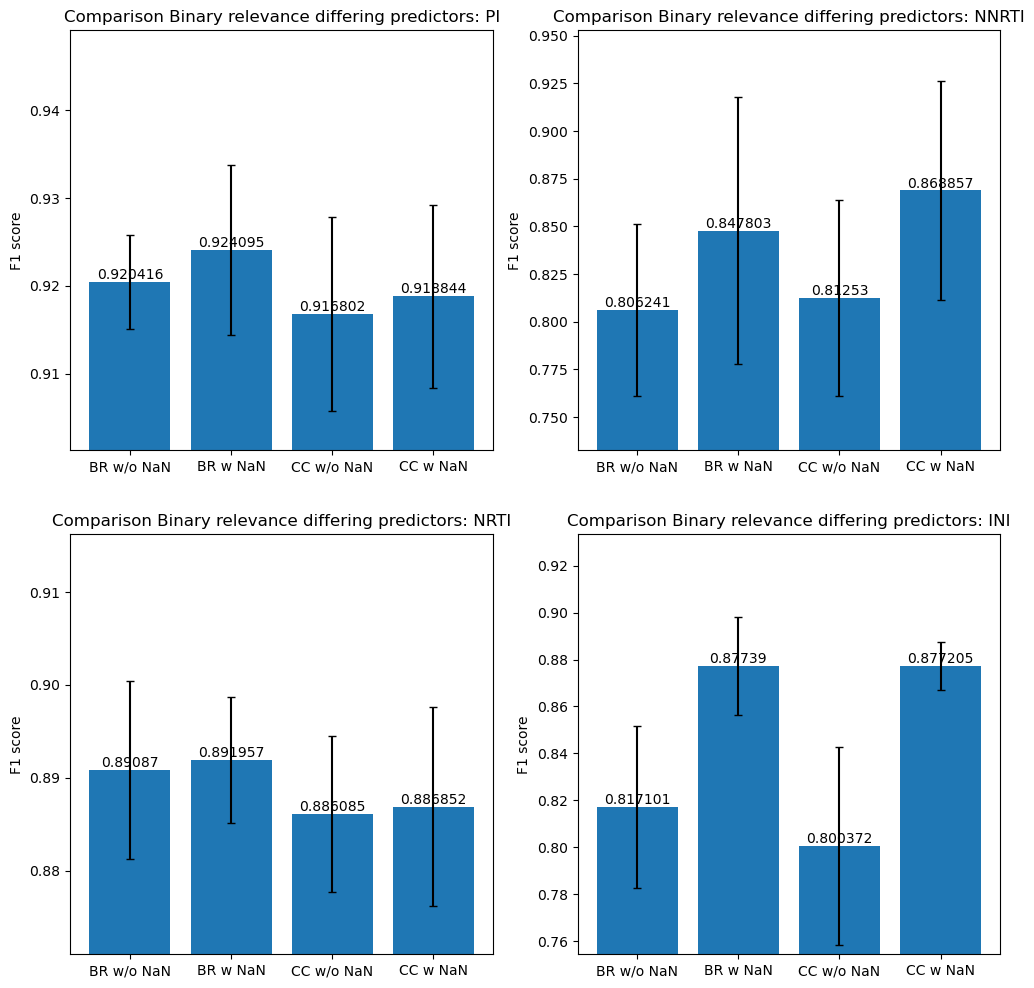

In [25]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: f1_score(x.filter(regex="True_*"),x.filter(regex="Pred_*"), average="weighted", zero_division="warn"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('F1 score')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


#plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new_wCCNaN_jaccMacro.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


In [ ]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: f1_score(x.filter(regex="True_*"),x.filter(regex="Pred_*"), average="weighted", zero_division="warn"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('F1 score')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


#plt.savefig("../figures/BR_CC_kfold_model_comparison_CCownCV_new_wCCNaN_jaccMacro.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")
